# Credit Risk Modeling - Credit Approval Scoring

## Step 1: Problem Definition and Dataset Description

Financial institutions must assess the risk that a borrower will default before granting credit.
The objective of this project is to build a **credit scoring model** that estimates the probability of default for credit card clients.
This score can be used to support credit approval decisions and risk segmentation.

### Dataset Description

Dataset: Default of Credit Card Clients (Taiwan, 2005)

Observations: 30,000 clients  

The target variable is: default.payment.next.month

1 = client defaults next month  

0 = client does not default

| **Variable**                    | **Description**                                                                                                                       |
|---------------------------------|---------------------------------------------------------------------------------------------------------------------------------------|
| **ID**                          | Identifiant unique du client.                                                                                                         |
| **LIMIT_BAL**                   | Montant du crédit accordé en dollars NT (inclut crédit individuel et familial/supplémentaire).                                         |
| **SEX**                         | Genre du client (1 = homme, 2 = femme).                                                                                               |
| **EDUCATION**                   | Niveau d’éducation (1 = école supérieure, 2 = université, 3 = lycée, 4 = autres, 5 = inconnu, 6 = inconnu).                           |
| **MARRIAGE**                    | Statut matrimonial (1 = marié, 2 = célibataire, 3 = autres).                                                                         |
| **AGE**                         | Âge du client en années.                                                                                                               |
| **PAY_0**                       | Statut de paiement en septembre 2005 (-1 = paiement à temps, 1 = retard d’un mois, 2 = retard de deux mois, …, 9 = retard de neuf mois ou plus). |
| **PAY_2**                       | Statut de paiement en août 2005 (même échelle que PAY_0).                                                                             |
| **PAY_3**                       | Statut de paiement en juillet 2005 (même échelle que PAY_0).                                                                            |
| **PAY_4**                       | Statut de paiement en juin 2005 (même échelle que PAY_0).                                                                               |
| **PAY_5**                       | Statut de paiement en mai 2005 (même échelle que PAY_0).                                                                                |
| **PAY_6**                       | Statut de paiement en avril 2005 (même échelle que PAY_0).                                                                              |
| **BILL_AMT1**                   | Montant de la facture pour septembre 2005 (en dollars NT).                                                                              |
| **BILL_AMT2**                   | Montant de la facture pour août 2005 (en dollars NT).                                                                                   |
| **BILL_AMT3**                   | Montant de la facture pour juillet 2005 (en dollars NT).                                                                                |
| **BILL_AMT4**                   | Montant de la facture pour juin 2005 (en dollars NT).                                                                                   |
| **BILL_AMT5**                   | Montant de la facture pour mai 2005 (en dollars NT).                                                                                    |
| **BILL_AMT6**                   | Montant de la facture pour avril 2005 (en dollars NT).                                                                                  |
| **PAY_AMT1**                    | Montant du paiement effectué en septembre 2005 (en dollars NT).                                                                         |
| **PAY_AMT2**                    | Montant du paiement effectué en août 2005 (en dollars NT).                                                                              |
| **PAY_AMT3**                    | Montant du paiement effectué en juillet 2005 (en dollars NT).                                                                           |
| **PAY_AMT4**                    | Montant du paiement effectué en juin 2005 (en dollars NT).                                                                              |
| **PAY_AMT5**                    | Montant du paiement effectué en mai 2005 (en dollars NT).                                                                               |
| **PAY_AMT6**                    | Montant du paiement effectué en avril 2005 (en dollars NT).                                                                             |
| **default.payment.next.month**  | Indicateur de défaut de paiement pour le mois suivant (1 = oui, 0 = non).                                                               |


## Step 2: Data Understanding

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('UCI_Credit_Card.csv')
print(data.shape)



(30000, 25)


In [2]:
print(data.columns)


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


In [3]:
data.head(5)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
data.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
# Transforming categorical columns to 'object' type
categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']

for col in categorical_columns:
    data[col] = data[col].astype('object')


###  Data quality checks

In [7]:
import pandas as pd
import numpy as np

# Affichage des valeurs manquantes par colonne
print(data.isnull().sum())


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [8]:
data.duplicated().sum()

0

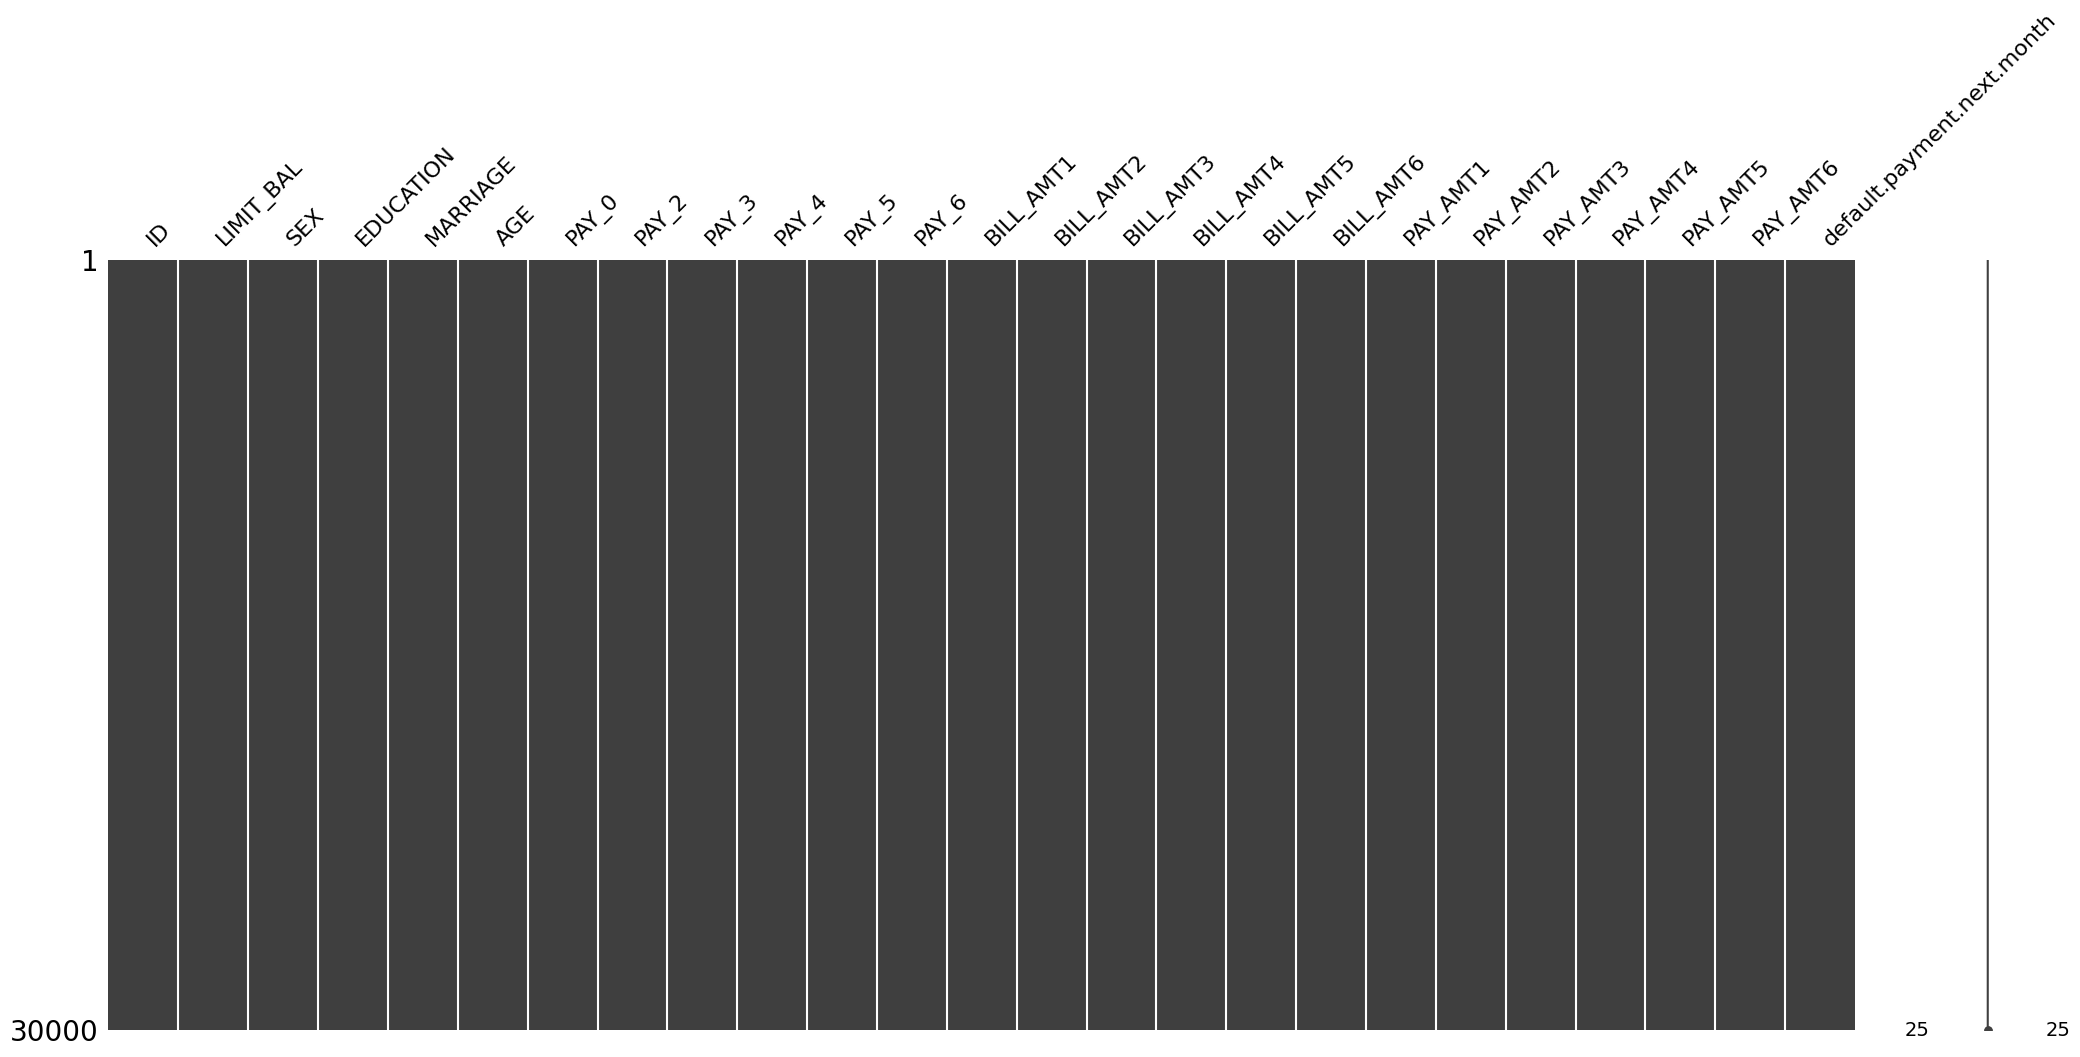

In [9]:
# Visualization missing values using missingno
import missingno as msno
import matplotlib.pyplot as plt
# Visualisation des valeurs manquantes
msno.matrix(data)
plt.show()


C:\Users\Etudiant\AppData\Roaming\Python\Python311\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
C:\Users\Etudiant\AppData\Roaming\Python\Python311\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


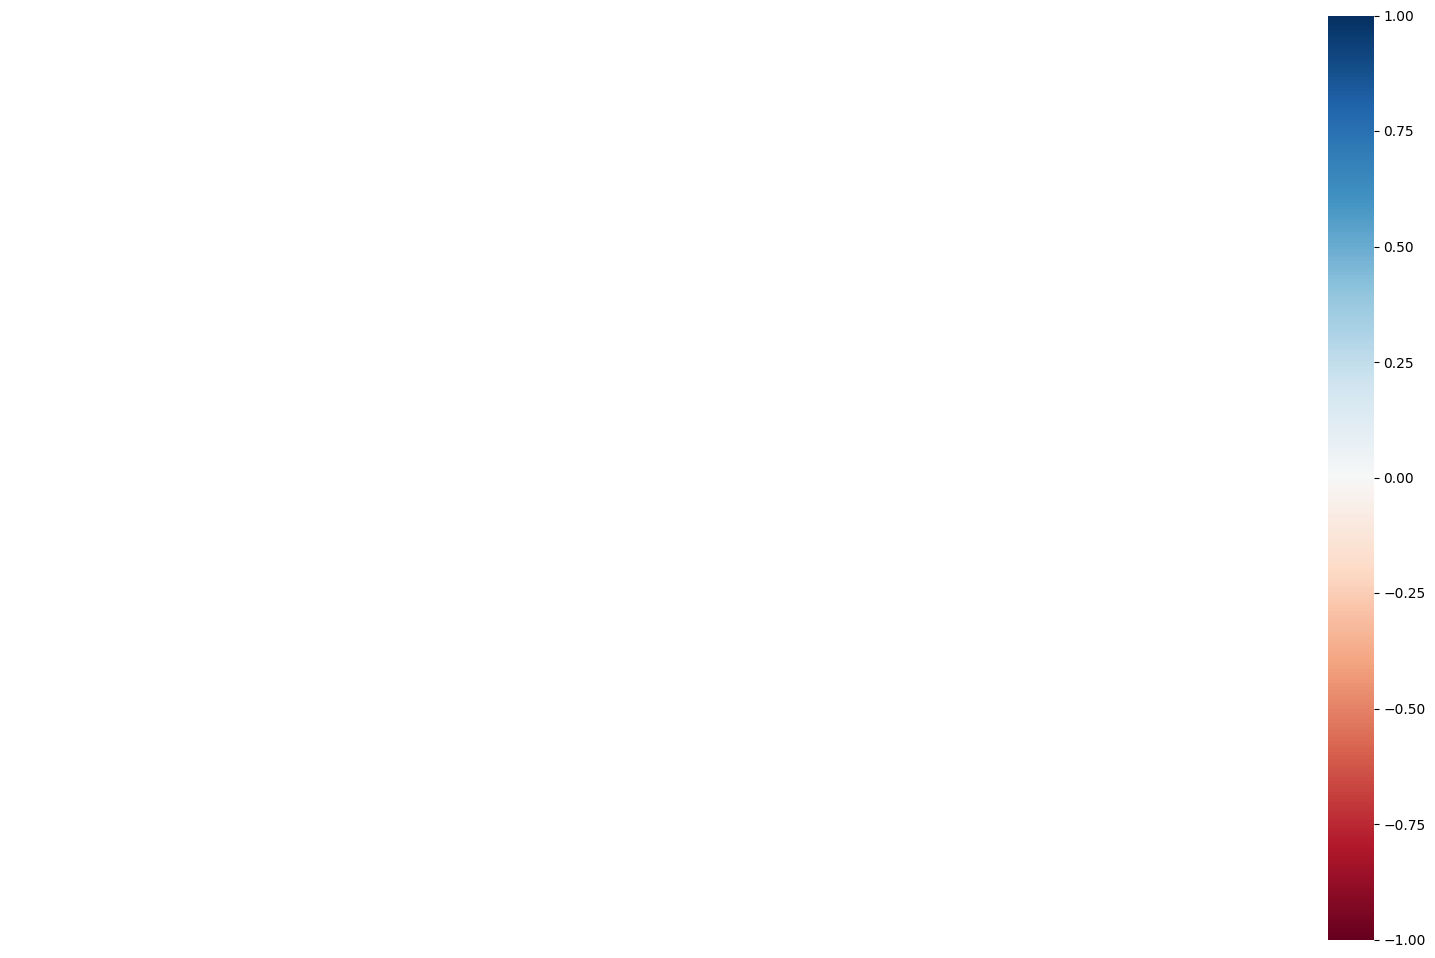

In [10]:

msno.heatmap(data)
plt.show()

## Step 3: Exploratory Data Analysis (EDA)

### Numerical variables analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

def analyze_numeric_features(data):
    """
    Analyze numerical features in the dataset.

    This function computes descriptive statistics and visualizes
    the distribution of numerical variables using boxplots,
    histograms and QQ-plots.
    """

    numeric_vars = data.select_dtypes(include=['number'])

    stats_summary = numeric_vars.describe().T
    stats_summary["median"] = numeric_vars.median()

    display(stats_summary)

    for col in numeric_vars.columns:

        plt.figure(figsize=(16,5))

        # Boxplot
        plt.subplot(1,3,1)
        sns.boxplot(y=numeric_vars[col], color="lightblue")
        plt.title(f"Boxplot - {col}")

        # Histogram
        plt.subplot(1,3,2)
        sns.histplot(numeric_vars[col], bins=30, kde=True)
        plt.title(f"Histogram - {col}")

        # QQ Plot
        plt.subplot(1,3,3)
        stats.probplot(numeric_vars[col].dropna(), dist="norm", plot=plt)
        plt.title(f"QQ Plot - {col}")

        plt.tight_layout()
        plt.show()

    return stats_summary

,count,mean,std,min,25%,50%,75%,max,median
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0,15000.5
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0,140000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0,34.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0,22381.5
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0,21200.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0,20088.5
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0,19052.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0,18104.5
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0,17071.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0,2100.0


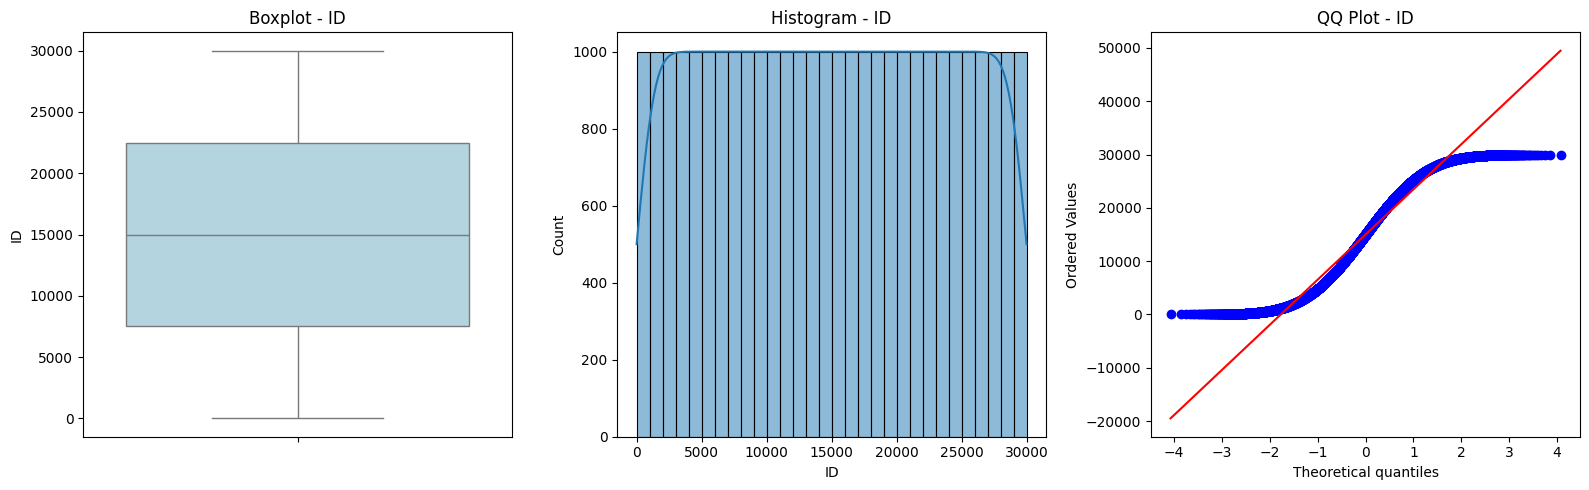

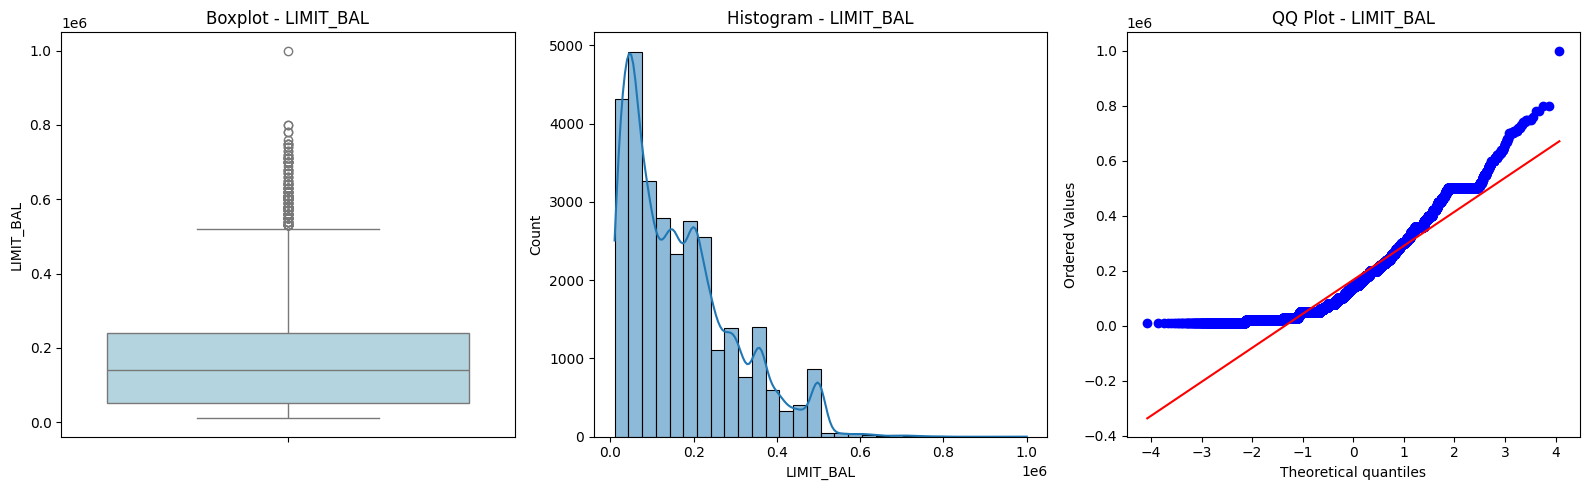

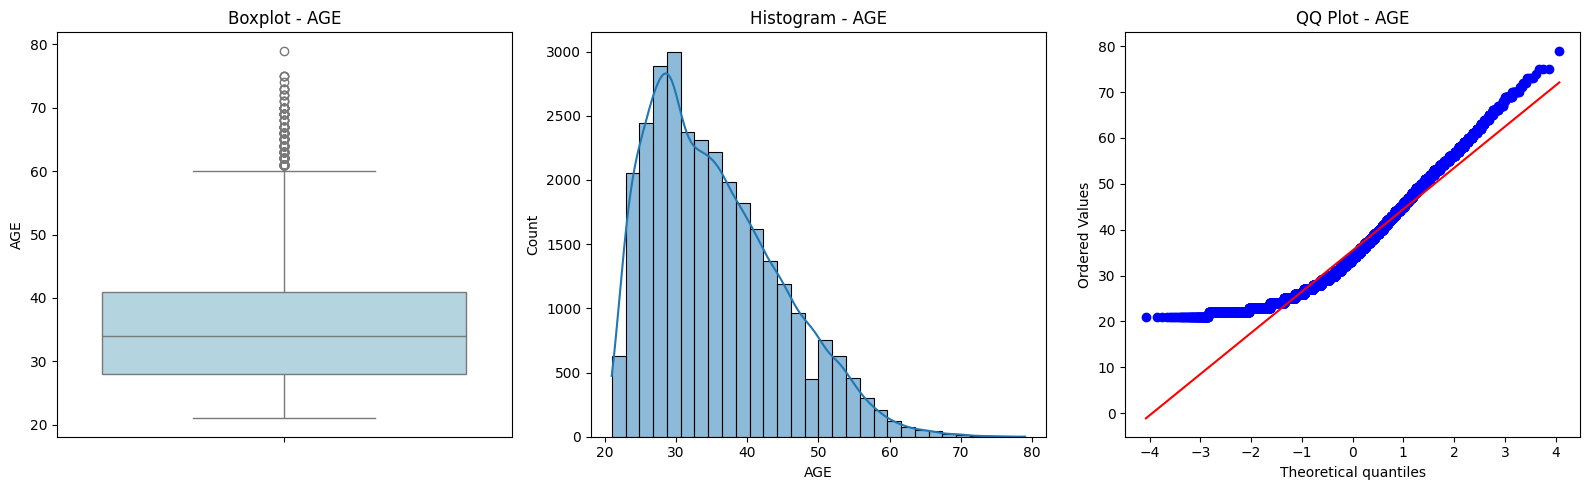

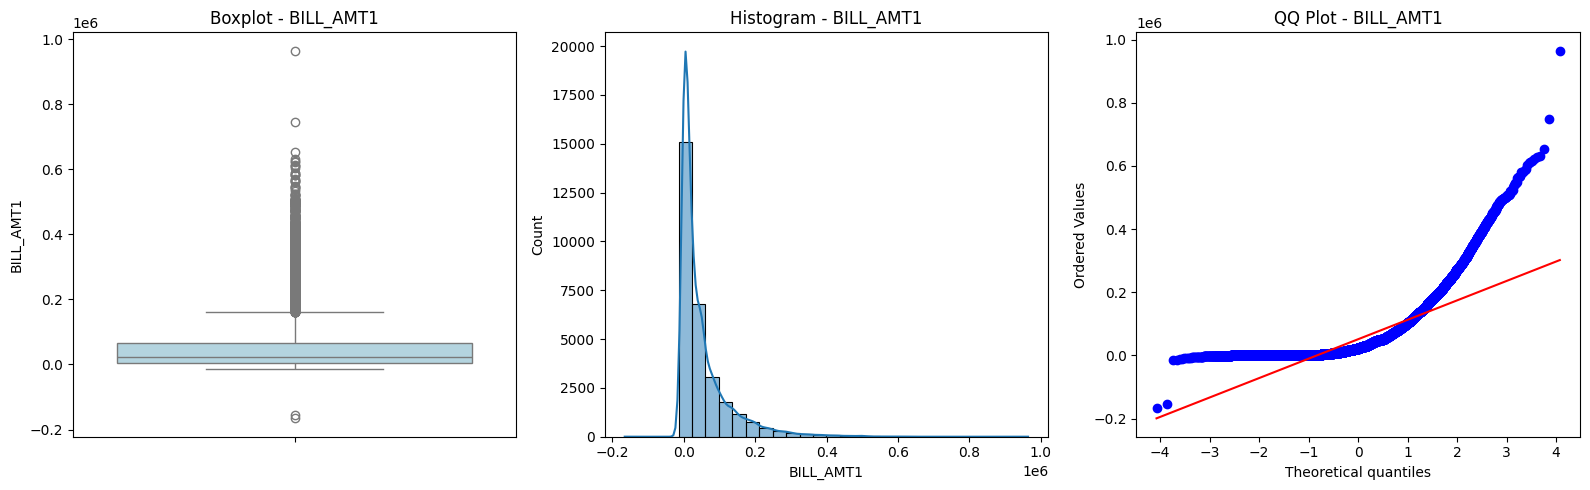

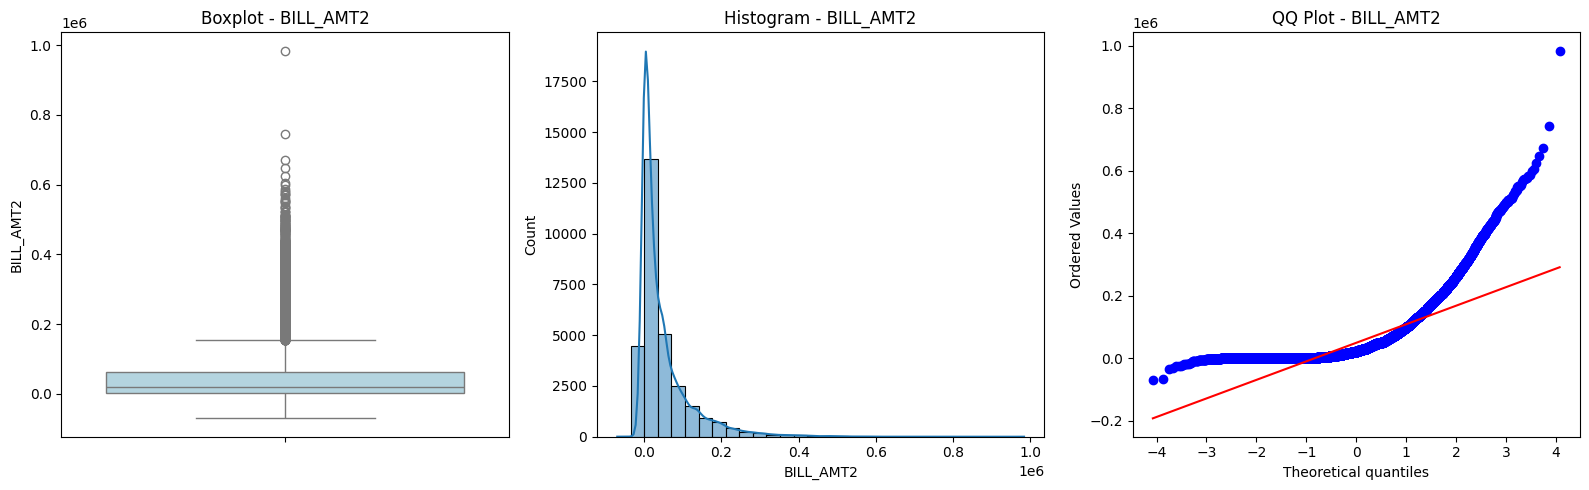

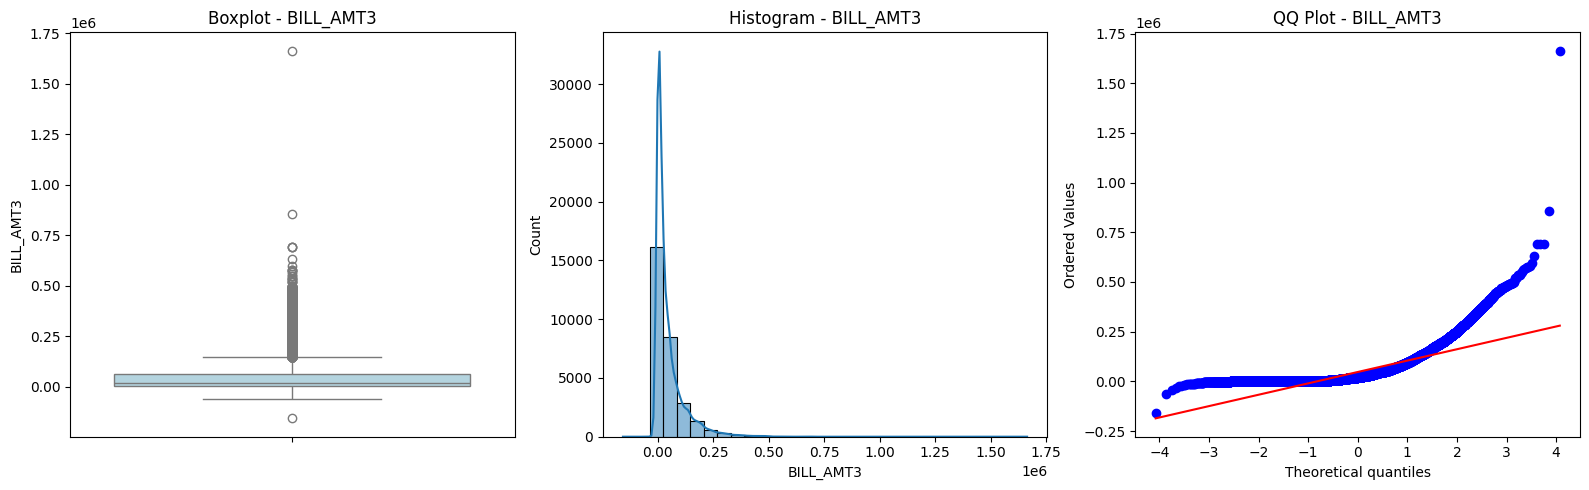

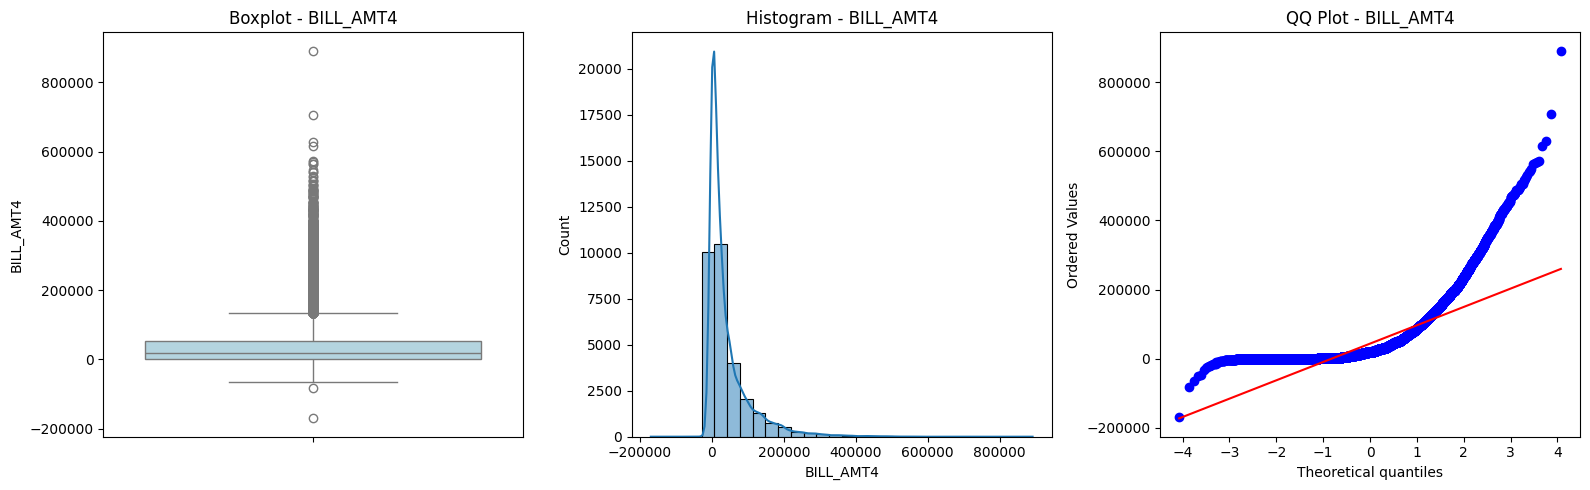

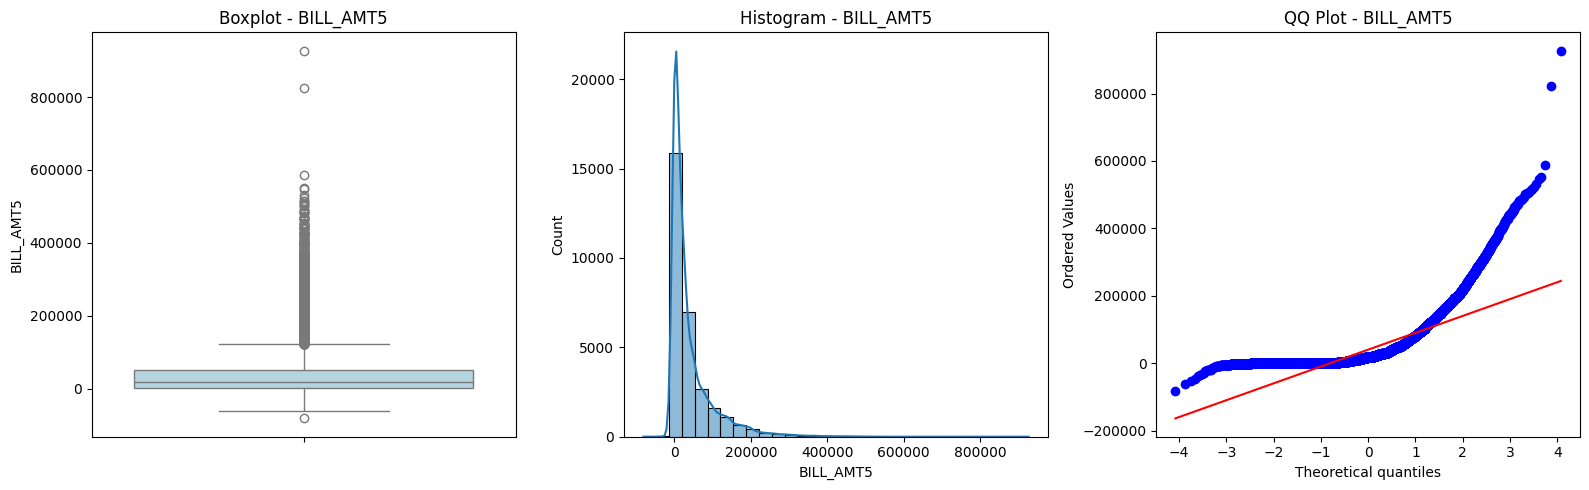

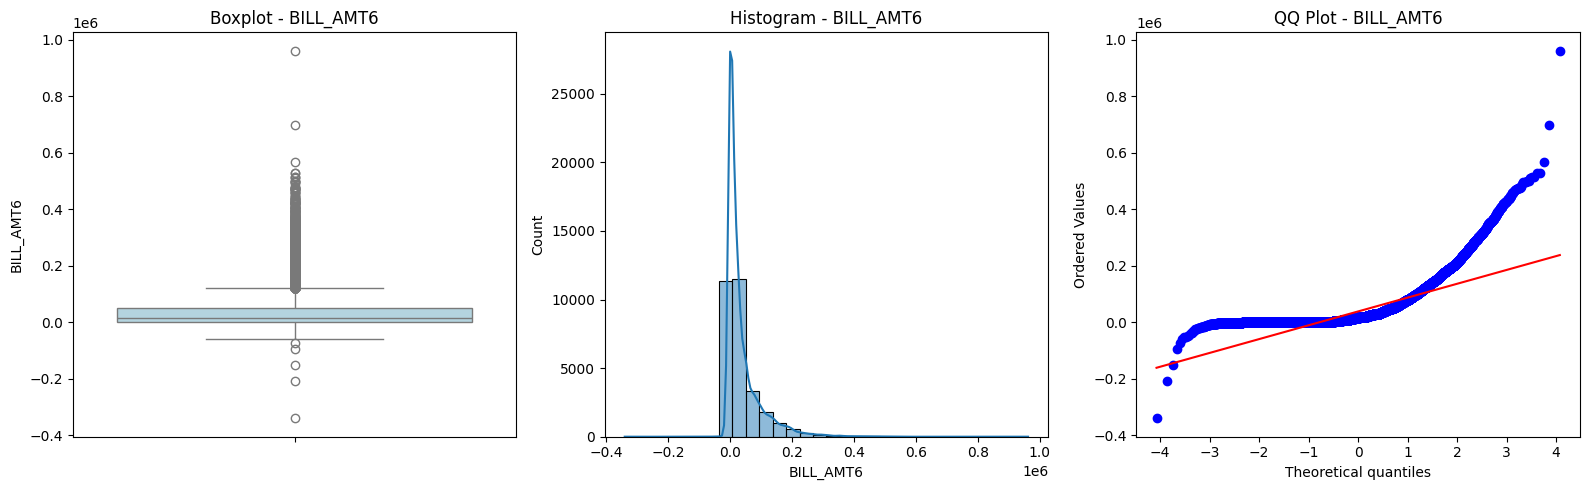

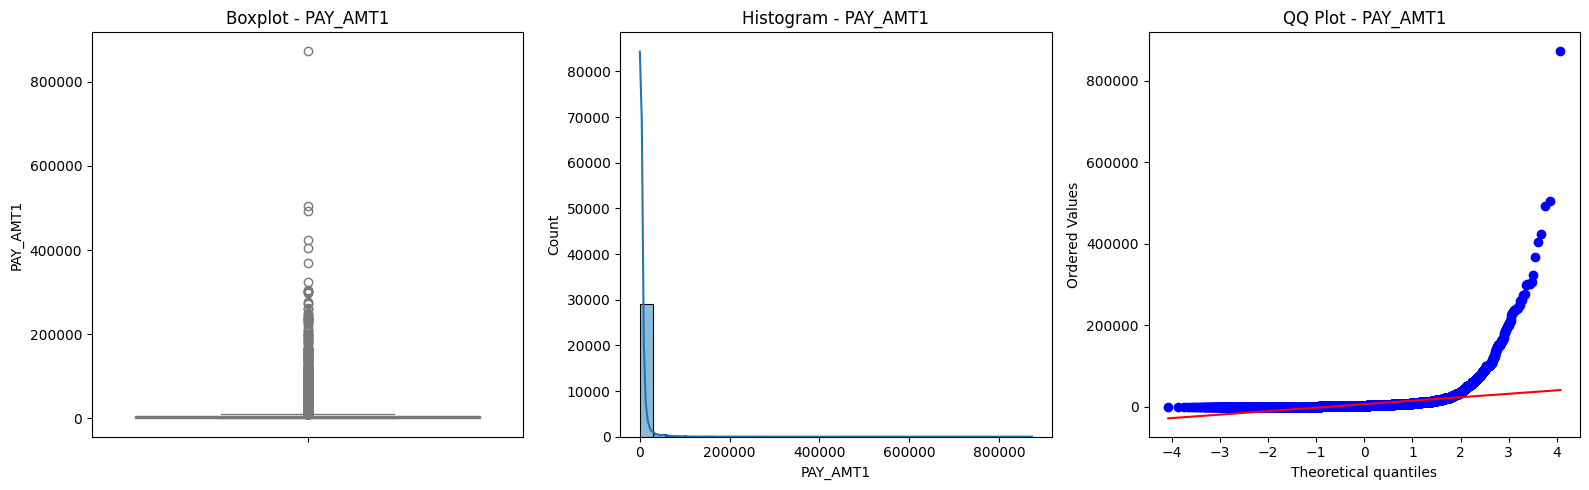

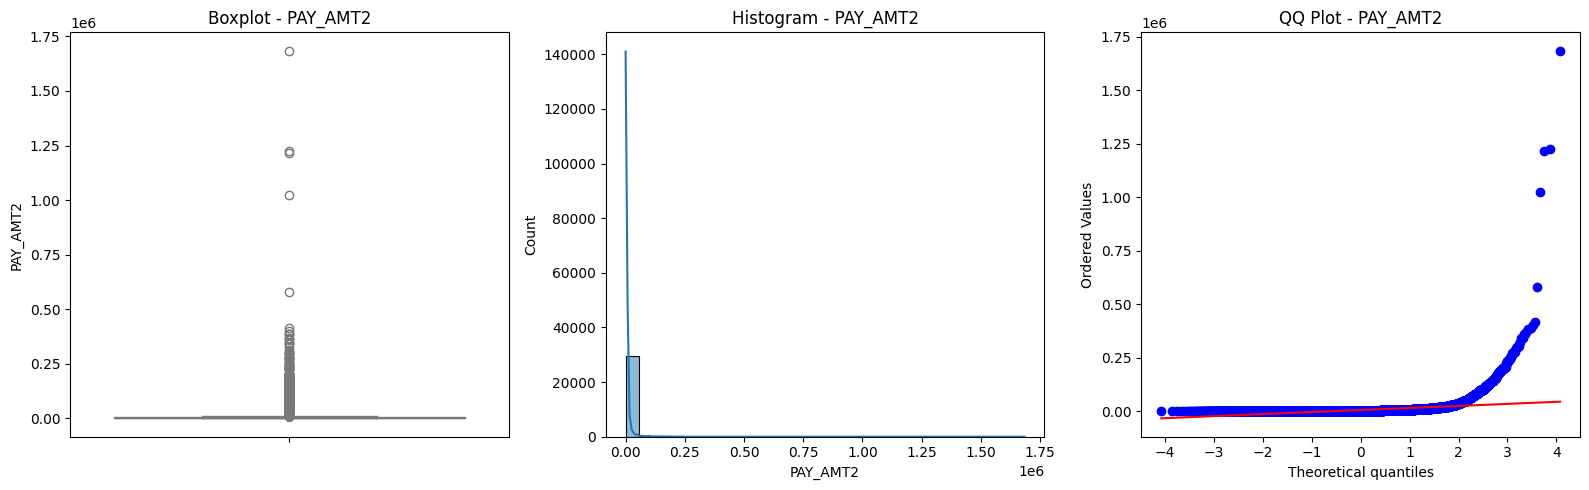

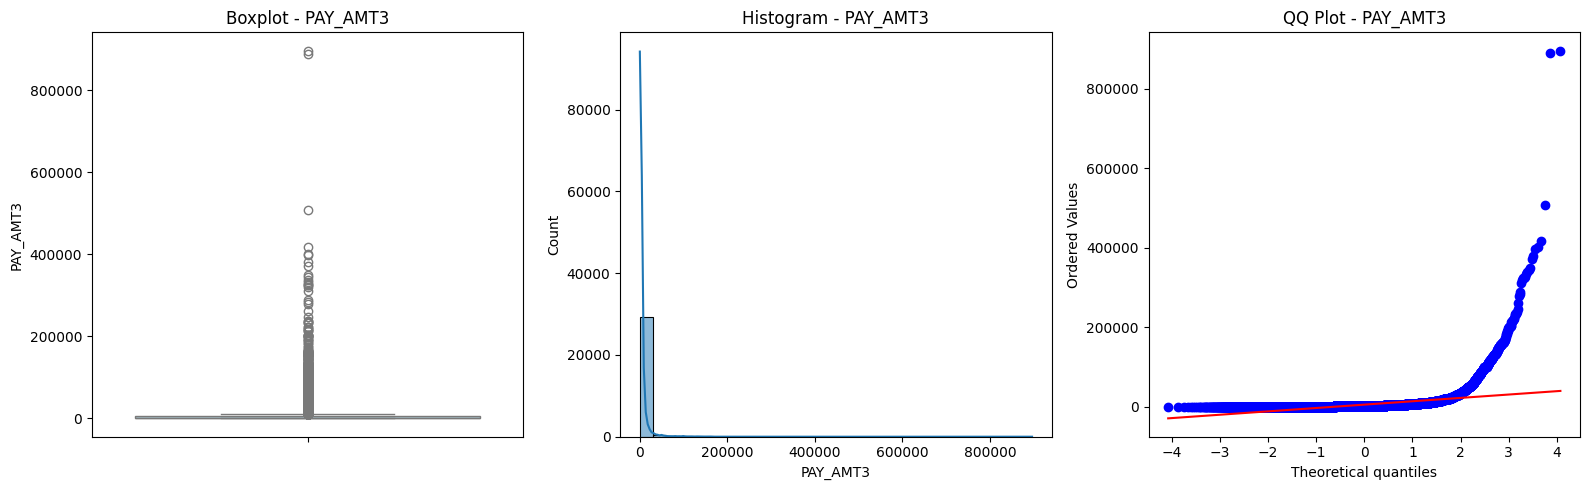

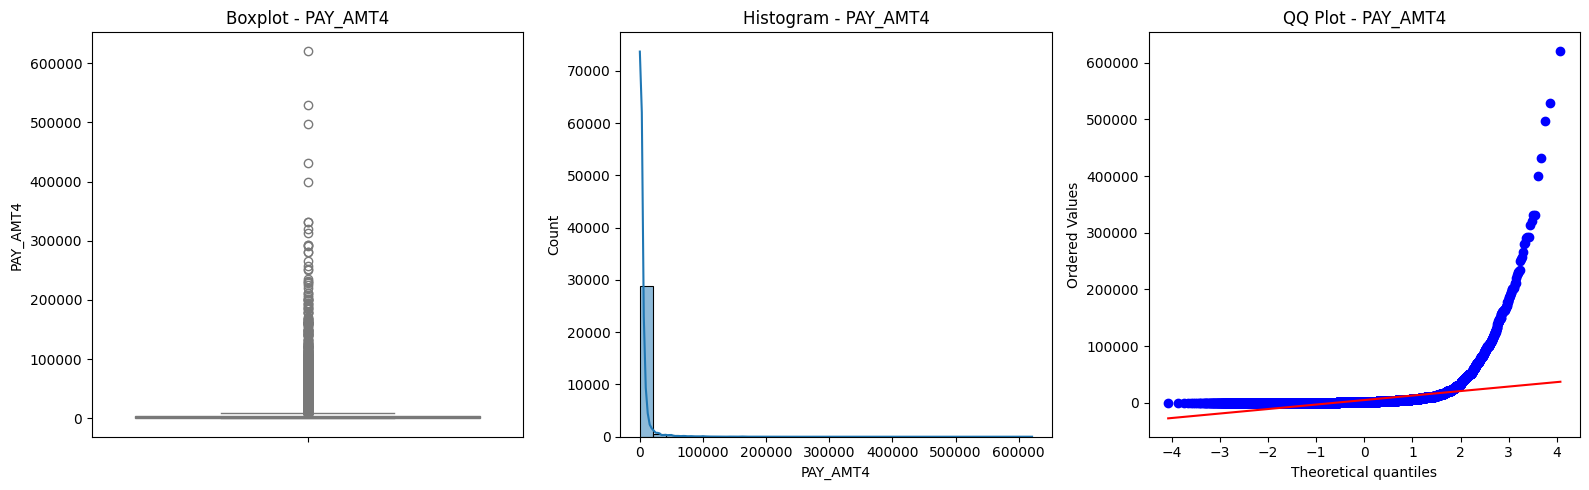

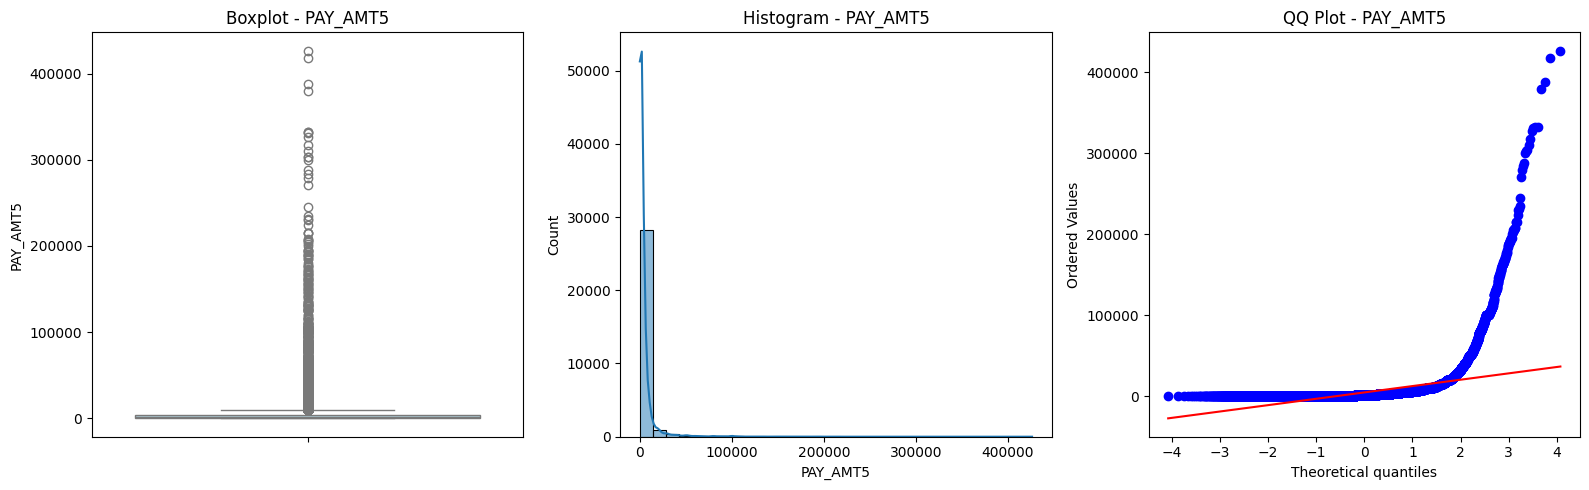

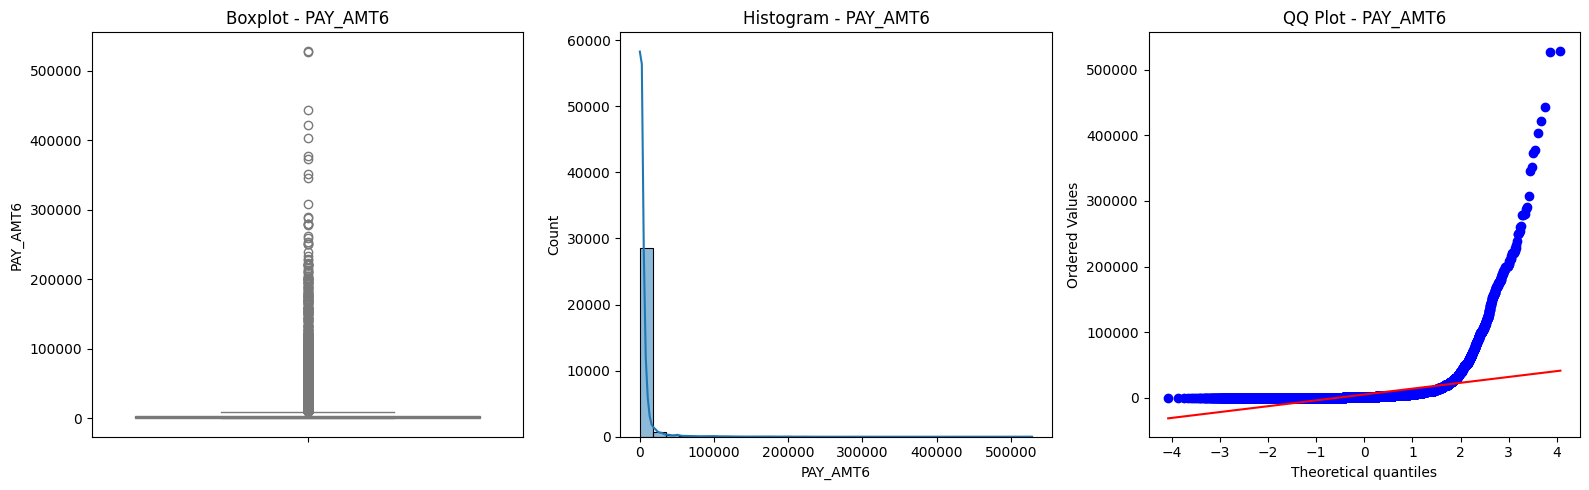

In [12]:
# Descriptive statistics and visualizations for numerical features

stats_summary = analyze_numeric_features (data)

<Axes: xlabel='default.payment.next.month', ylabel='LIMIT_BAL'>

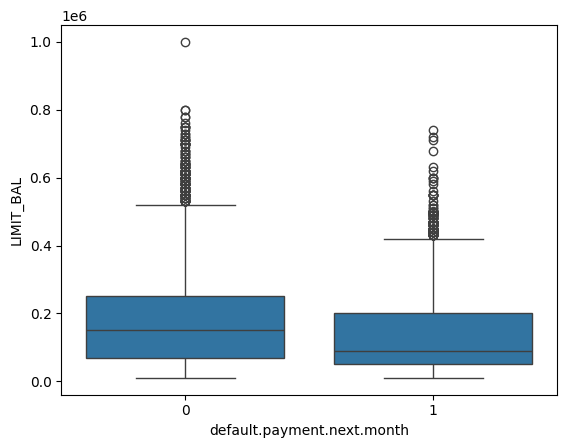

In [13]:
# Boxplot of LIMIT_BAL by default.payment.next.month
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=data)

<Axes: xlabel='default.payment.next.month', ylabel='AGE'>

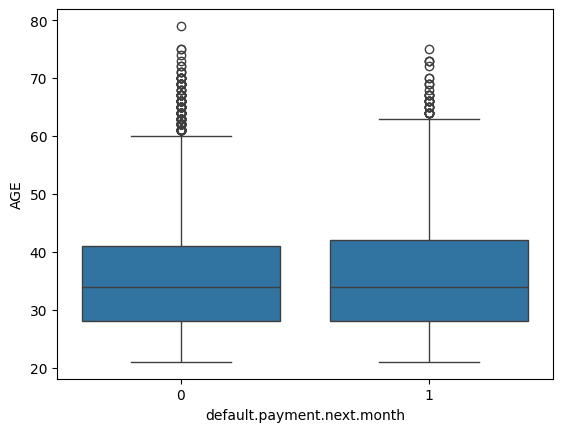

In [14]:
# Boxplot of AGE by default.payment.next.month
sns.boxplot(x='default.payment.next.month', y='AGE', data=data)

### Description and visualization of categorical features


Frequency table - SEX


,Count,Proportion (%)
SEX,,
2,18112,60.37
1,11888,39.63


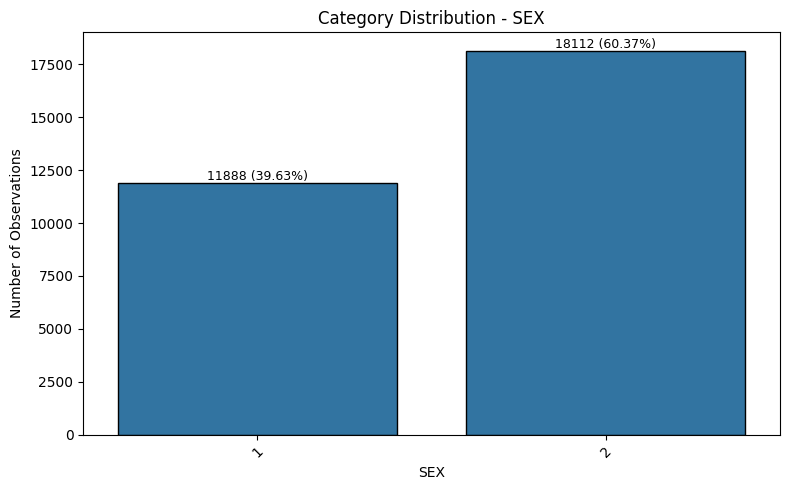


Frequency table - EDUCATION


,Count,Proportion (%)
EDUCATION,,
2,14030,46.77
1,10585,35.28
3,4917,16.39
5,280,0.93
4,123,0.41
6,51,0.17
0,14,0.05


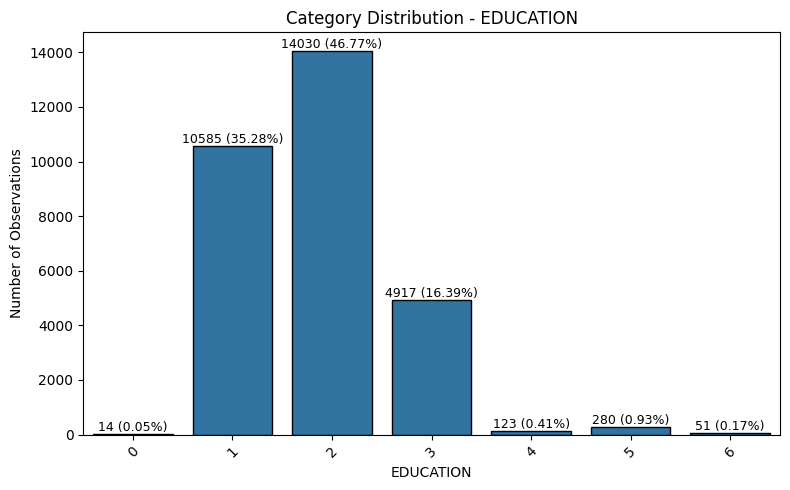


Frequency table - MARRIAGE


,Count,Proportion (%)
MARRIAGE,,
2,15964,53.21
1,13659,45.53
3,323,1.08
0,54,0.18


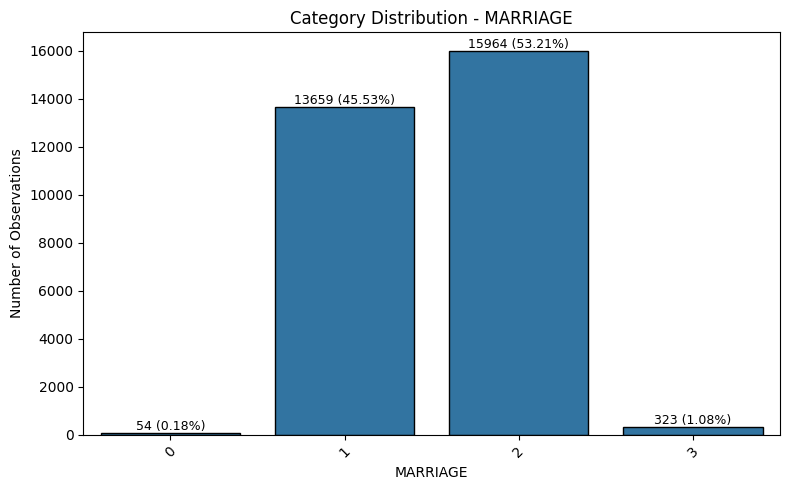


Frequency table - PAY_0


,Count,Proportion (%)
PAY_0,,
0,14737,49.12
-1,5686,18.95
1,3688,12.29
-2,2759,9.20
2,2667,8.89
3,322,1.07
4,76,0.25
5,26,0.09
8,19,0.06


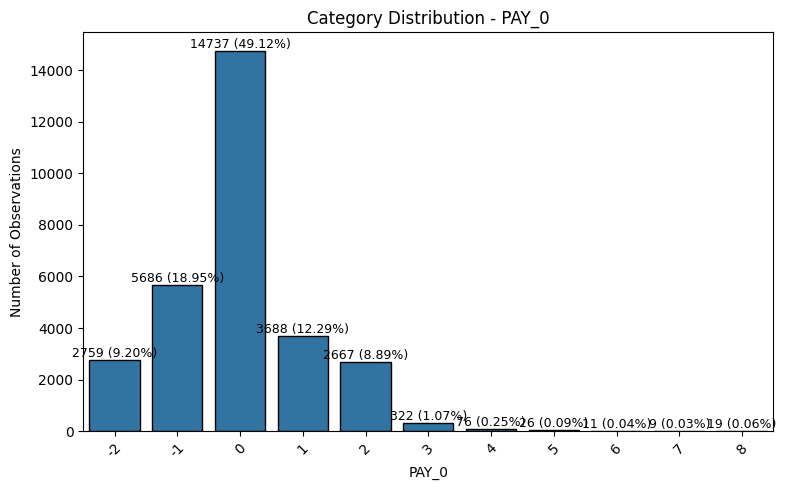


Frequency table - PAY_2


,Count,Proportion (%)
PAY_2,,
0,15730,52.43
-1,6050,20.17
2,3927,13.09
-2,3782,12.61
3,326,1.09
4,99,0.33
1,28,0.09
5,25,0.08
7,20,0.07


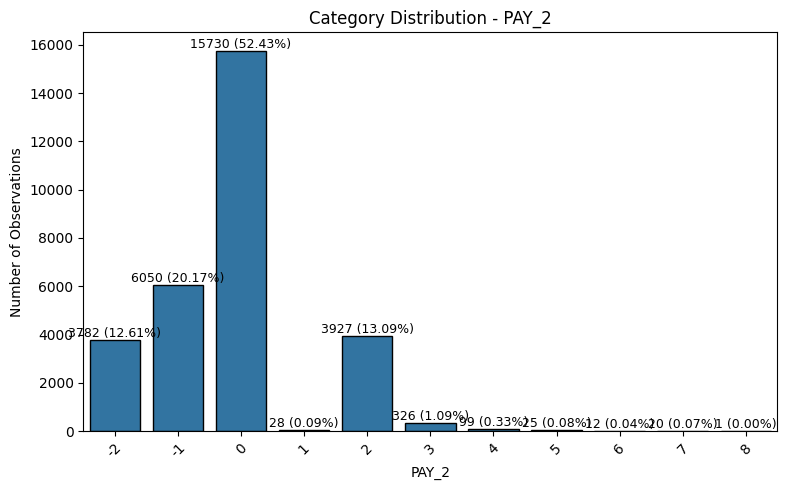


Frequency table - PAY_3


,Count,Proportion (%)
PAY_3,,
0,15764,52.55
-1,5938,19.79
-2,4085,13.62
2,3819,12.73
3,240,0.80
4,76,0.25
7,27,0.09
6,23,0.08
5,21,0.07


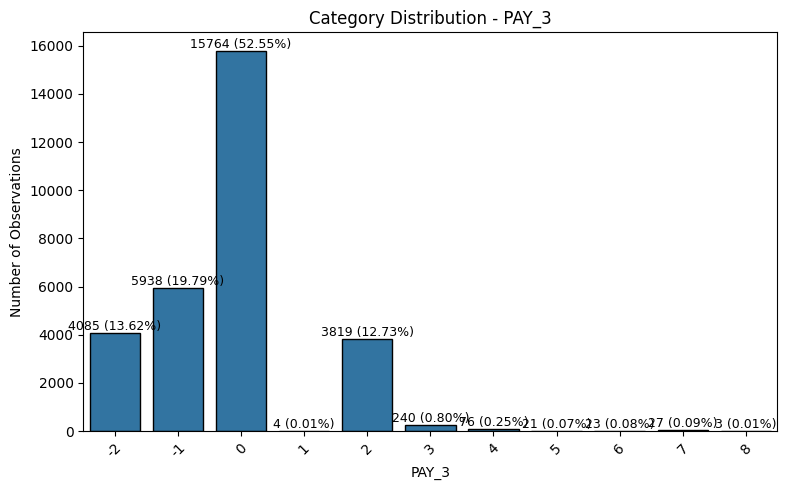


Frequency table - PAY_4


,Count,Proportion (%)
PAY_4,,
0,16455,54.85
-1,5687,18.96
-2,4348,14.49
2,3159,10.53
3,180,0.60
4,69,0.23
7,58,0.19
5,35,0.12
6,5,0.02


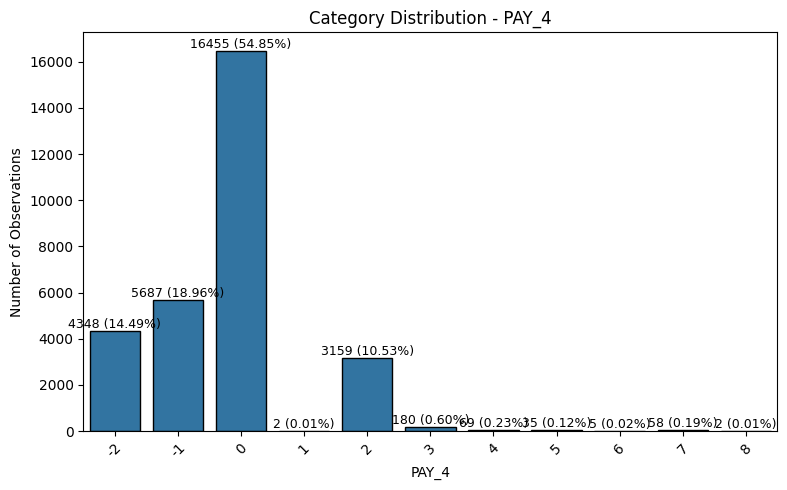


Frequency table - PAY_5


,Count,Proportion (%)
PAY_5,,
0,16947,56.49
-1,5539,18.46
-2,4546,15.15
2,2626,8.75
3,178,0.59
4,84,0.28
7,58,0.19
5,17,0.06
6,4,0.01


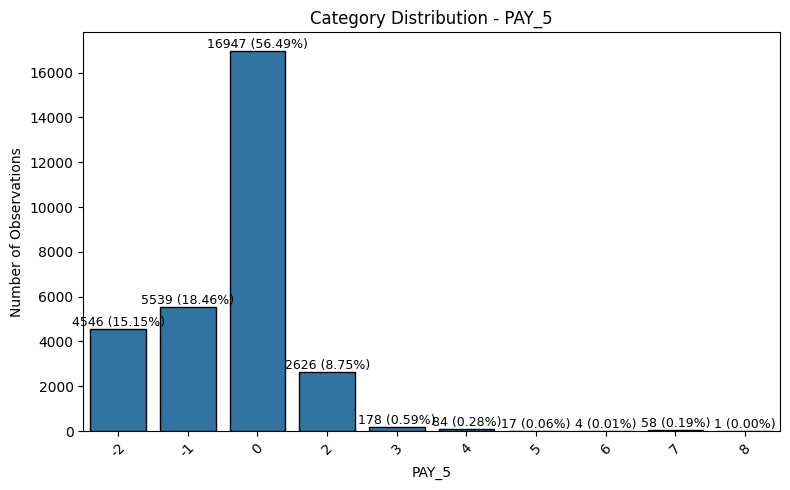


Frequency table - PAY_6


,Count,Proportion (%)
PAY_6,,
0,16286,54.29
-1,5740,19.13
-2,4895,16.32
2,2766,9.22
3,184,0.61
4,49,0.16
7,46,0.15
6,19,0.06
5,13,0.04


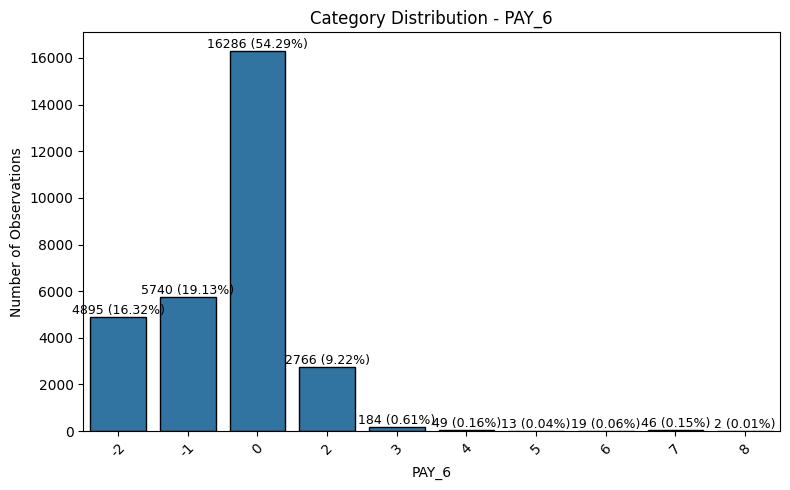


Frequency table - default.payment.next.month


,Count,Proportion (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


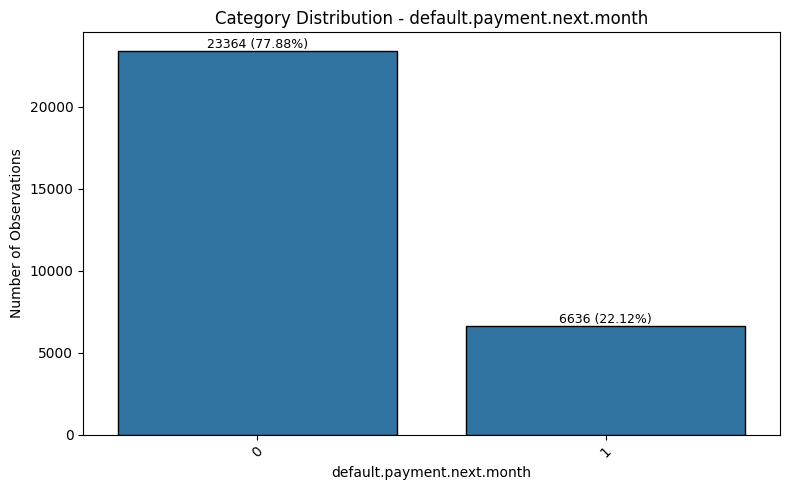

{'SEX':      Count  Proportion (%)
 SEX                       
 2    18112           60.37
 1    11888           39.63,
 'EDUCATION':            Count  Proportion (%)
 EDUCATION                       
 2          14030           46.77
 1          10585           35.28
 3           4917           16.39
 5            280            0.93
 4            123            0.41
 6             51            0.17
 0             14            0.05,
 'MARRIAGE':           Count  Proportion (%)
 MARRIAGE                       
 2         15964           53.21
 1         13659           45.53
 3           323            1.08
 0            54            0.18,
 'PAY_0':        Count  Proportion (%)
 PAY_0                       
 0      14737           49.12
 -1      5686           18.95
 1       3688           12.29
 -2      2759            9.20
 2       2667            8.89
 3        322            1.07
 4         76            0.25
 5         26            0.09
 8         19            0.06
 6        

In [ ]:
def analyze_categorical_features(data, categorical_cols=None):
    """
    Analyze categorical features in the dataset.

    This function displays:
    - frequency tables
    - percentage distribution
    - bar plots with counts and proportions

    Parameters
    ----------
    data : pandas.DataFrame
        Input dataset.
    categorical_cols : list, optional
        List of categorical columns to analyze.
        If None, columns with dtype 'object' or 'category' are selected.

    Returns
    -------
    dict
        Dictionary containing frequency tables for each categorical feature.
    """

    if categorical_cols is None:
        categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()

    results = {}

    for col in categorical_cols:
        freq_table = data[col].value_counts(dropna=False)
        proportions = (freq_table / len(data) * 100).round(2)

        freq_df = pd.DataFrame({
            "Count": freq_table,
            "Proportion (%)": proportions
        })

        print(f"\nFrequency table - {col}")
        display(freq_df)

        # Bar plot with counts and proportions
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x=data[col], edgecolor="black")
        plt.title(f"Category Distribution - {col}")
        plt.xlabel(col)
        plt.ylabel("Number of Observations")
        plt.xticks(rotation=45)

        # Annotate bars with counts and proportions
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(
                f"{int(height)} ({(height/len(data)*100):.2f}%)",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()

        results[col] = freq_df

    return results

# Analyze categorical features
analyze_categorical_features (data)

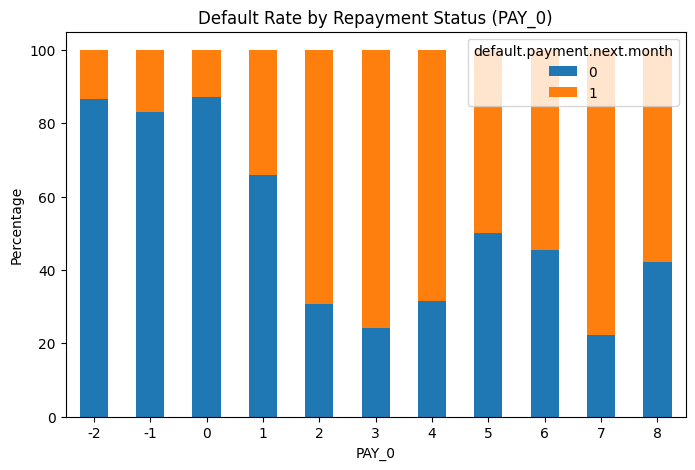

In [18]:
# Default rate by repayment status (PAY_0)
default_by_pay0 = pd.crosstab(
    data["PAY_0"],
    data["default.payment.next.month"],
    normalize="index"
) * 100

default_by_pay0.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Default Rate by Repayment Status (PAY_0)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Alternative: Displaying the crosstab directly
pd.crosstab(data["PAY_0"], data["default.payment.next.month"], normalize="index") * 100

default.payment.next.month,0,1
PAY_0,,
-2,86.770569,13.229431
-1,83.221949,16.778051
0,87.188709,12.811291
1,66.052061,33.947939
2,30.858643,69.141357
3,24.223602,75.776398
4,31.578947,68.421053
5,50.000000,50.000000
6,45.454545,54.545455


### Rare category grouping

In [20]:
# Replace values in EDUCATION column
data['EDUCATION'] = data['EDUCATION'].replace({
    0:'Other',
    4:'Other',
    5:'Other',
    6:'Other'
})

# Replace values in MARRIAGE column
data['MARRIAGE'] = data['MARRIAGE'].replace({
    0:'Other',
    3:'Other'
})

# Grouped repayment status (for EDA)

pay_columns = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_columns:
    data[f"{col}_grouped"] = data[col].replace({
        -2:'On time',
        -1:'On time',
        0:'On time',
        1:'Delay',
        2:'Delay',
        3:'Delay',
        4:'Delay',
        5:'Delay',
        6:'Delay',
        7:'Delay',
        8:'Delay'
    })


Frequency table - SEX


,Count,Proportion (%)
SEX,,
2,18112,60.37
1,11888,39.63


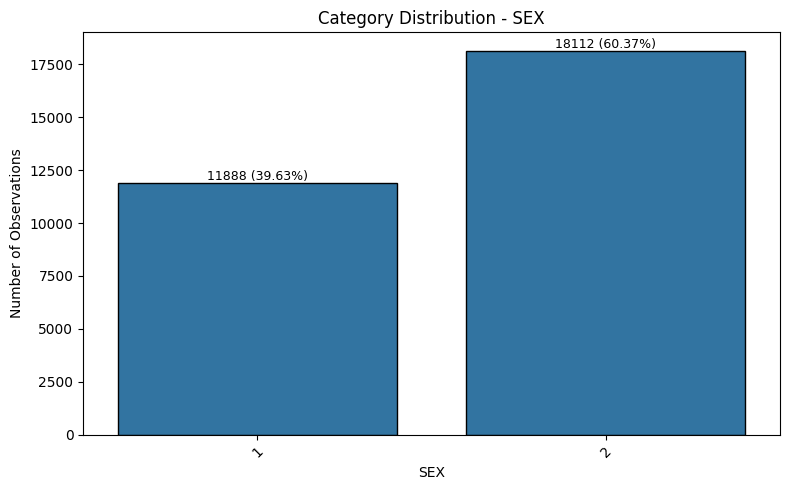


Frequency table - EDUCATION


,Count,Proportion (%)
EDUCATION,,
2,14030,46.77
1,10585,35.28
3,4917,16.39
Other,468,1.56


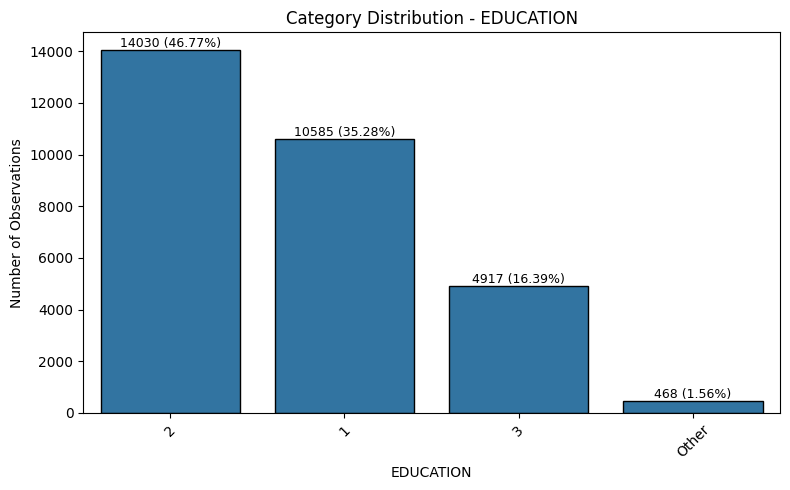


Frequency table - MARRIAGE


,Count,Proportion (%)
MARRIAGE,,
2,15964,53.21
1,13659,45.53
Other,377,1.26


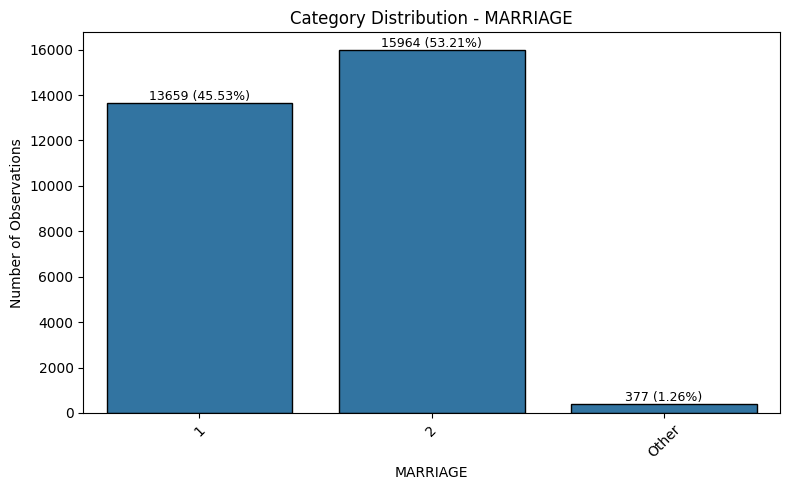


Frequency table - PAY_0


,Count,Proportion (%)
PAY_0,,
0,14737,49.12
-1,5686,18.95
1,3688,12.29
-2,2759,9.20
2,2667,8.89
3,322,1.07
4,76,0.25
5,26,0.09
8,19,0.06


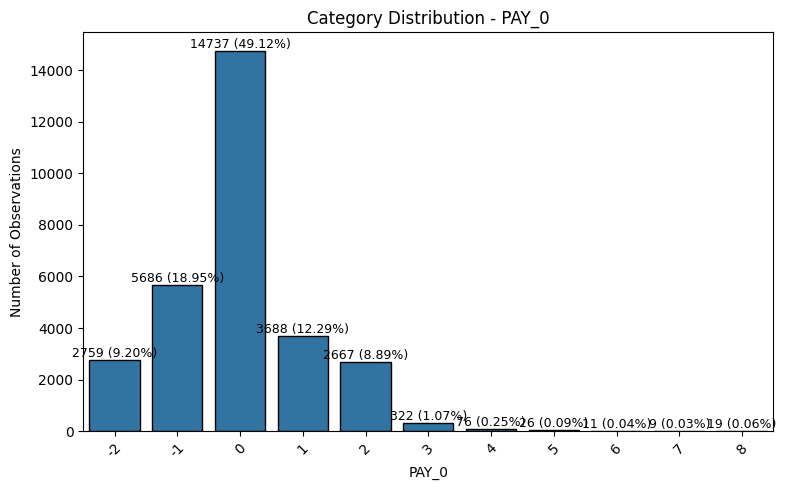


Frequency table - PAY_2


,Count,Proportion (%)
PAY_2,,
0,15730,52.43
-1,6050,20.17
2,3927,13.09
-2,3782,12.61
3,326,1.09
4,99,0.33
1,28,0.09
5,25,0.08
7,20,0.07


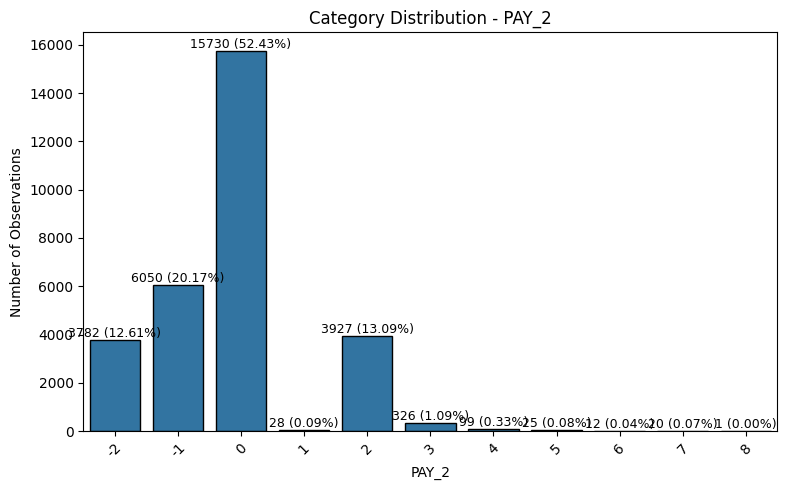


Frequency table - PAY_3


,Count,Proportion (%)
PAY_3,,
0,15764,52.55
-1,5938,19.79
-2,4085,13.62
2,3819,12.73
3,240,0.80
4,76,0.25
7,27,0.09
6,23,0.08
5,21,0.07


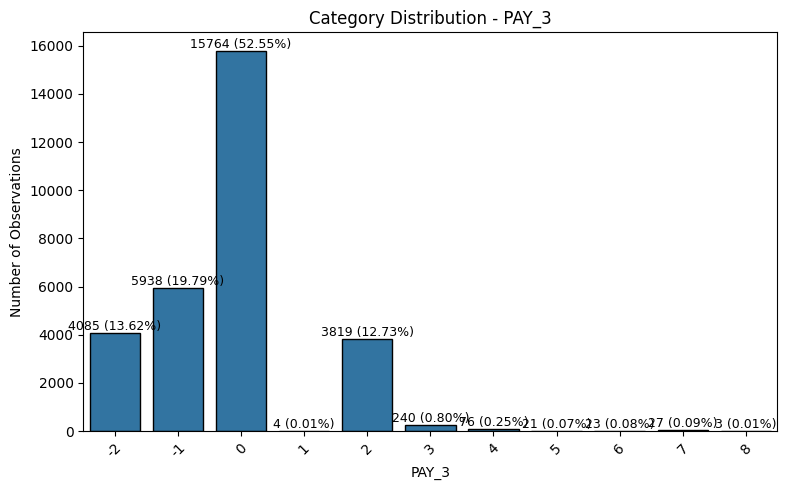


Frequency table - PAY_4


,Count,Proportion (%)
PAY_4,,
0,16455,54.85
-1,5687,18.96
-2,4348,14.49
2,3159,10.53
3,180,0.60
4,69,0.23
7,58,0.19
5,35,0.12
6,5,0.02


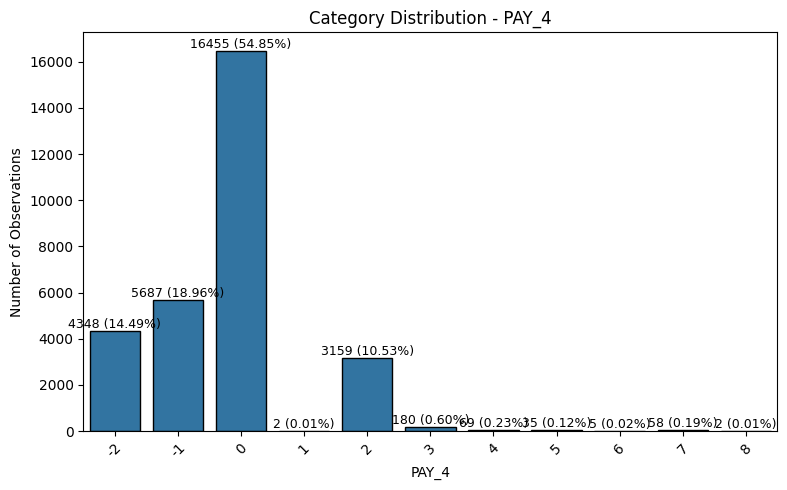


Frequency table - PAY_5


,Count,Proportion (%)
PAY_5,,
0,16947,56.49
-1,5539,18.46
-2,4546,15.15
2,2626,8.75
3,178,0.59
4,84,0.28
7,58,0.19
5,17,0.06
6,4,0.01


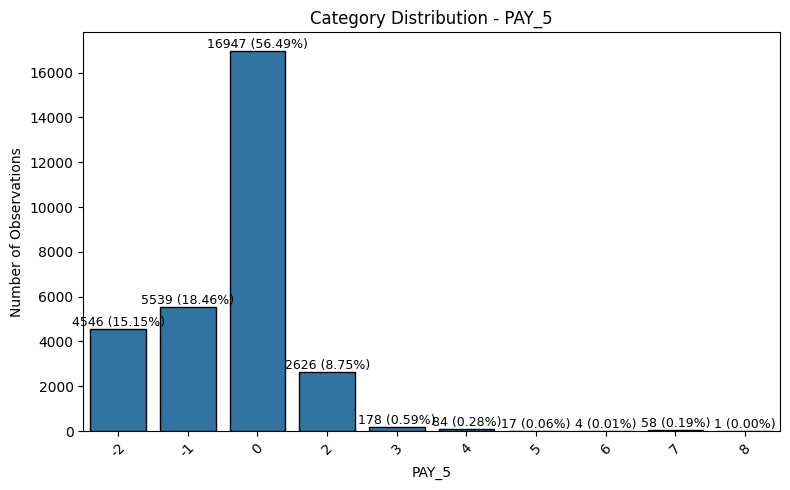


Frequency table - PAY_6


,Count,Proportion (%)
PAY_6,,
0,16286,54.29
-1,5740,19.13
-2,4895,16.32
2,2766,9.22
3,184,0.61
4,49,0.16
7,46,0.15
6,19,0.06
5,13,0.04


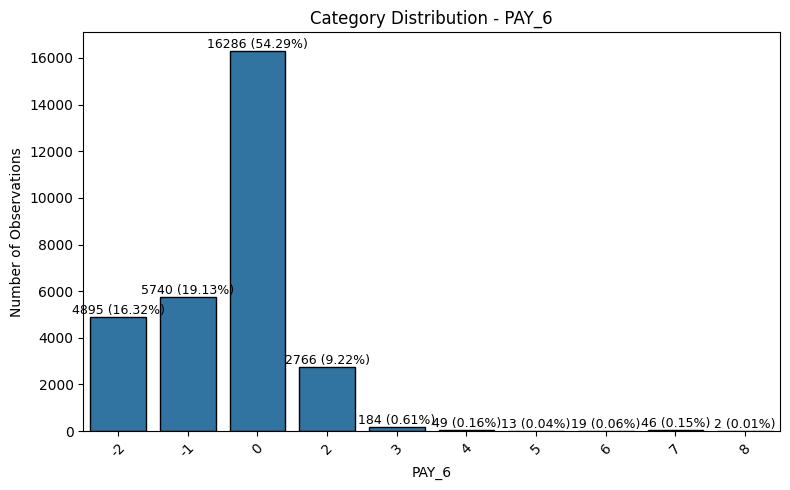


Frequency table - default.payment.next.month


,Count,Proportion (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


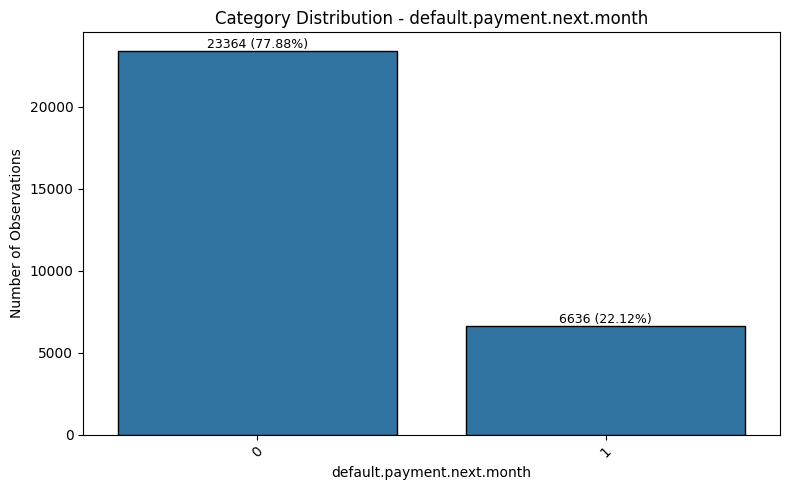


Frequency table - PAY_0_grouped


,Count,Proportion (%)
PAY_0_grouped,,
On time,23182,77.27
Delay,6818,22.73


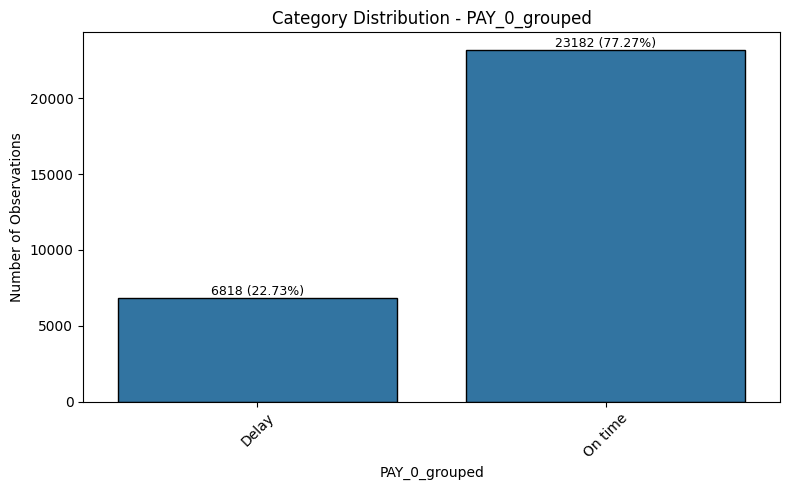


Frequency table - PAY_2_grouped


,Count,Proportion (%)
PAY_2_grouped,,
On time,25562,85.21
Delay,4438,14.79


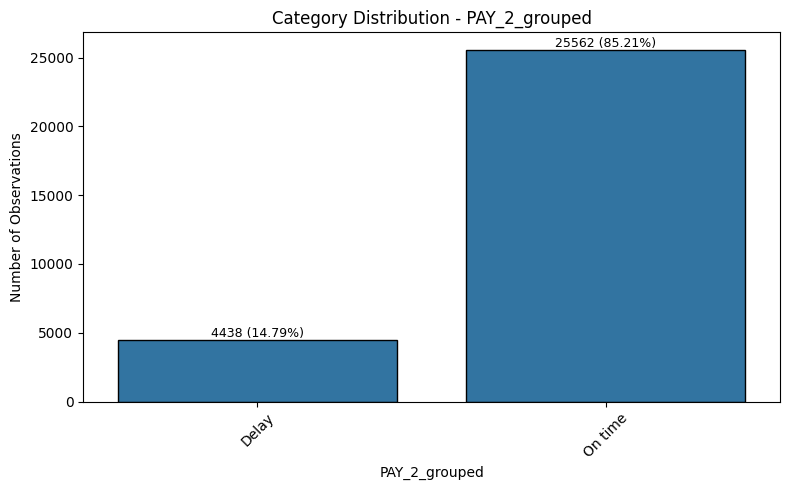


Frequency table - PAY_3_grouped


,Count,Proportion (%)
PAY_3_grouped,,
On time,25787,85.96
Delay,4213,14.04


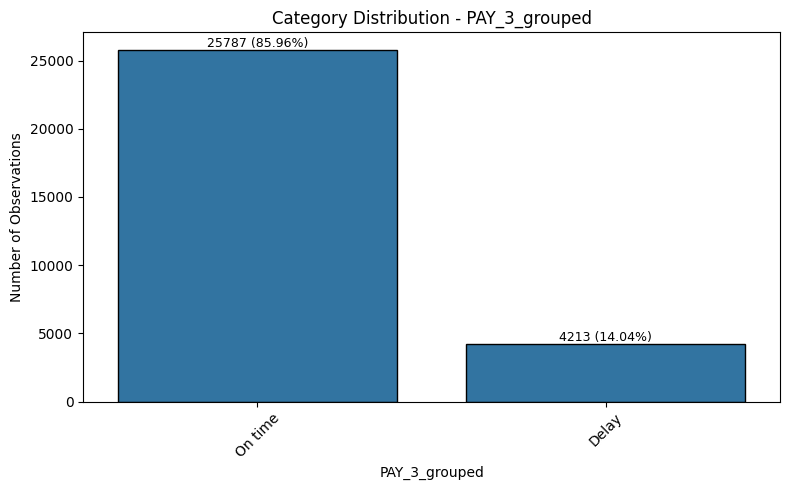


Frequency table - PAY_4_grouped


,Count,Proportion (%)
PAY_4_grouped,,
On time,26490,88.3
Delay,3510,11.7


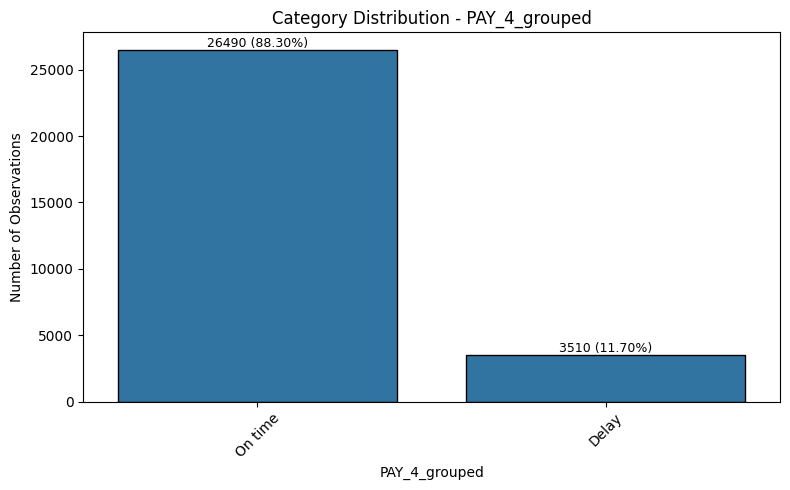


Frequency table - PAY_5_grouped


,Count,Proportion (%)
PAY_5_grouped,,
On time,27032,90.11
Delay,2968,9.89


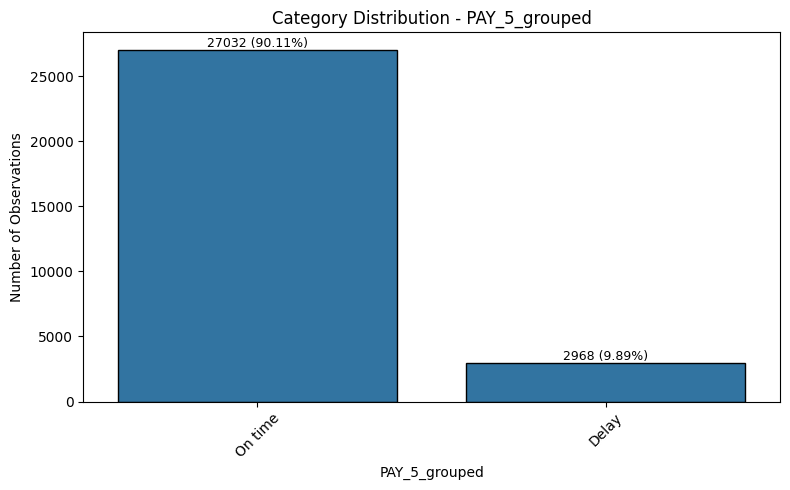


Frequency table - PAY_6_grouped


,Count,Proportion (%)
PAY_6_grouped,,
On time,26921,89.74
Delay,3079,10.26


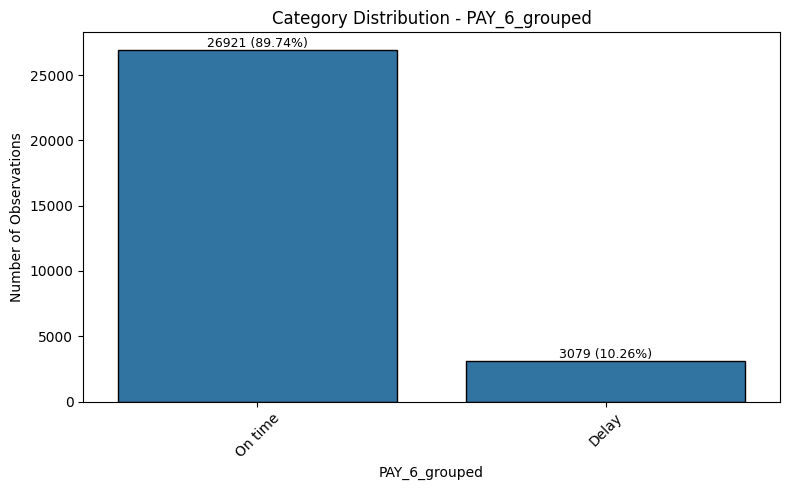

{'SEX':      Count  Proportion (%)
 SEX                       
 2    18112           60.37
 1    11888           39.63,
 'EDUCATION':            Count  Proportion (%)
 EDUCATION                       
 2          14030           46.77
 1          10585           35.28
 3           4917           16.39
 Other        468            1.56,
 'MARRIAGE':           Count  Proportion (%)
 MARRIAGE                       
 2         15964           53.21
 1         13659           45.53
 Other       377            1.26,
 'PAY_0':        Count  Proportion (%)
 PAY_0                       
 0      14737           49.12
 -1      5686           18.95
 1       3688           12.29
 -2      2759            9.20
 2       2667            8.89
 3        322            1.07
 4         76            0.25
 5         26            0.09
 8         19            0.06
 6         11            0.04
 7          9            0.03,
 'PAY_2':        Count  Proportion (%)
 PAY_2                       
 0      15730  

In [21]:
# Analyze categorical features
analyze_categorical_features (data)

<Axes: xlabel='PAY_0_grouped', ylabel='count'>

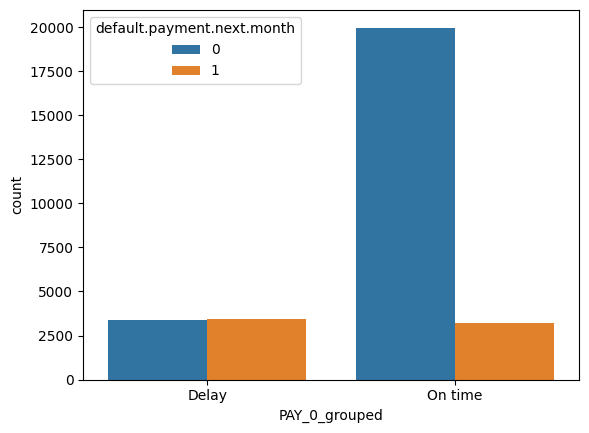

In [ ]:
# Visualize grouped repayment status 
sns.countplot(x='PAY_0_grouped', hue='default.payment.next.month', data=data)